In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import gseapy as gp
import os
import pickle

import subcluster_funcs as funcs
sc._settings.settings._vector_friendly=True

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [2]:
post_subclustering_dir = "../post_subcluster_annotation/"
os.makedirs(post_subclustering_dir, exist_ok=True)

In [3]:
cell_type = "Fibroblast"

In [4]:
adata = sc.read_h5ad("../post_subclustering/" + cell_type  + ".h5ad")

<Axes: xlabel='leiden', ylabel='sil_score'>

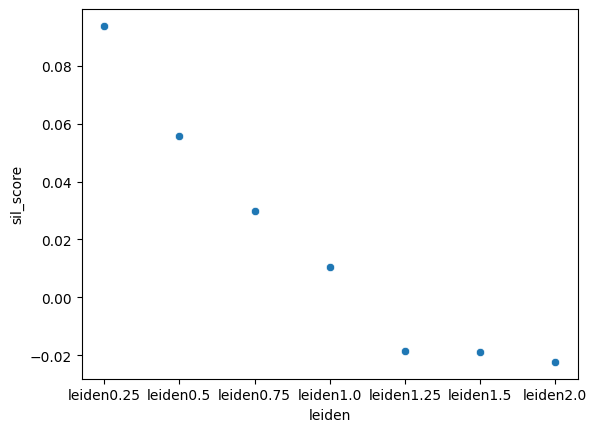

In [5]:
funcs.silhouette(adata, cell_type = cell_type)

### Use Leiden 0.25

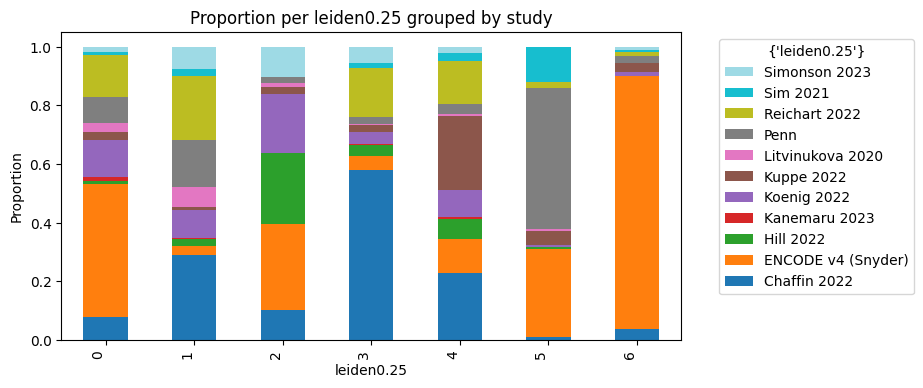

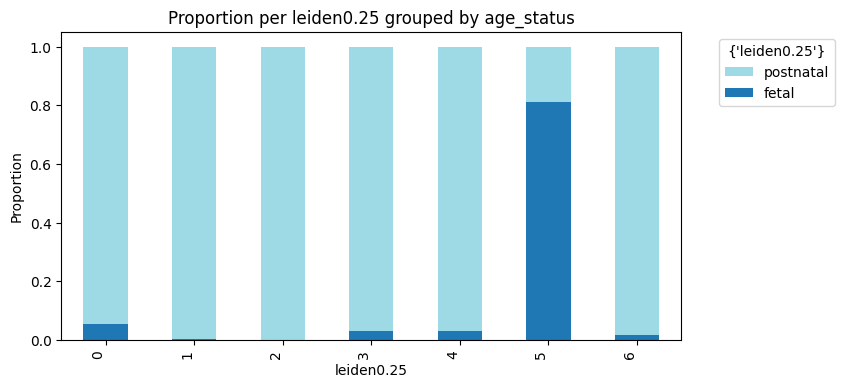

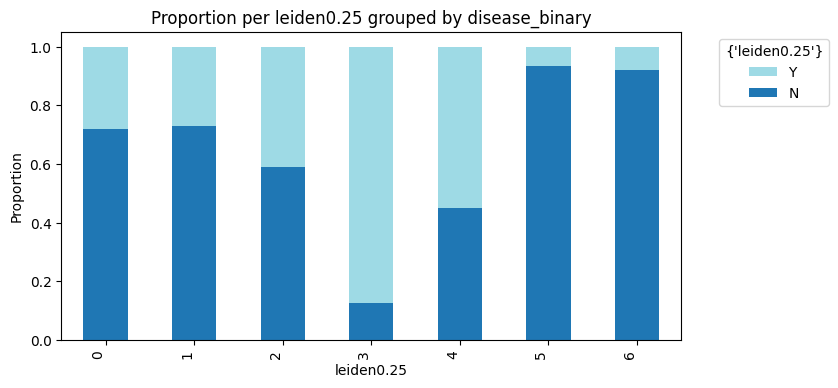

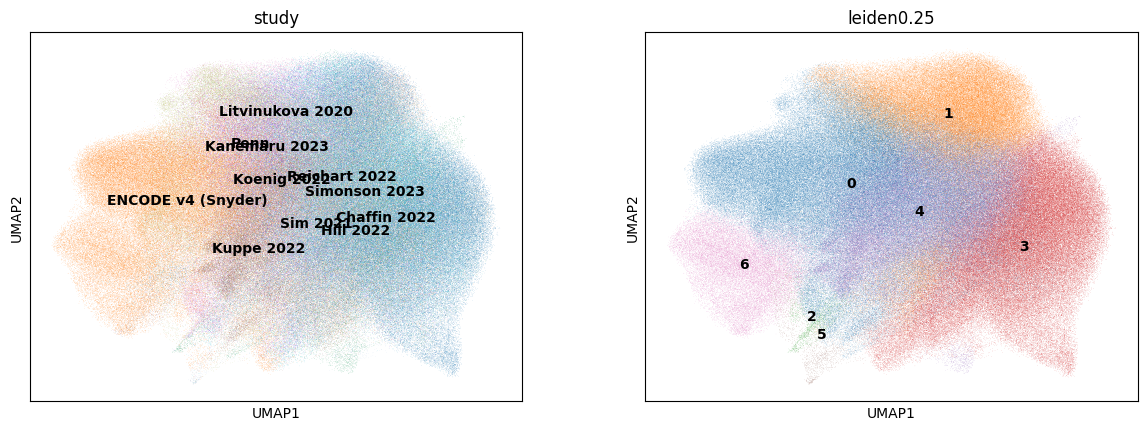

/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:459: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:459: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean

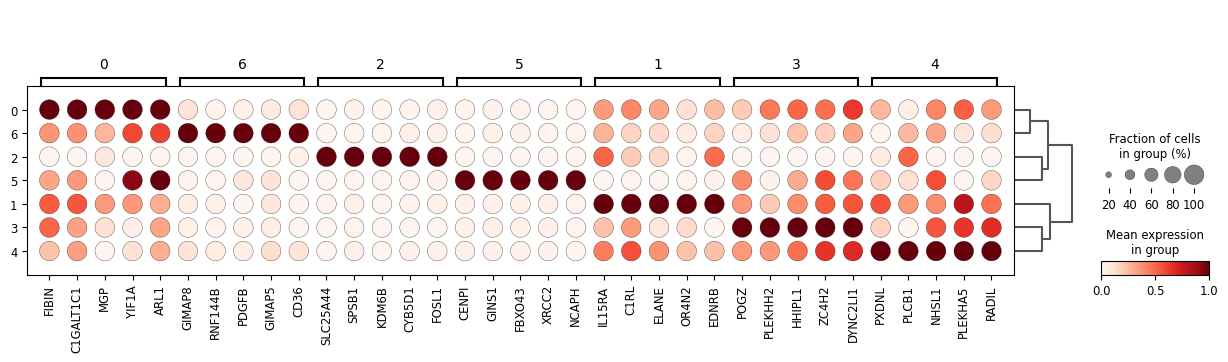

Counter({'0': 182994, '3': 141820, '1': 104747, '4': 87188, '6': 27490, '5': 2329, '2': 2045})
CPU times: user 1min 22s, sys: 3min 31s, total: 4min 53s
Wall time: 4min 58s


['leiden0.25',
 AnnData object with n_obs × n_vars = 548613 × 16115
     obs: 'age', 'donor_id', 'sex', 'region', 'cell_type', 'disease', 'consistent_cell_type', 'study', 'technology', 'cell_or_nuclei', 'barcode', 'sample_id', 'age_status', 'tech_plus_study', 'disease_binary', 'decade', 'age_group', '_scvi_batch', '_scvi_labels', 'leiden_scVI', 'scvi_cell_type', 'redo_leiden_0.5', 'UMAP1', 'UMAP2', 'v2_scvi_cell_type', 'final_cell_type', 'leiden0.1', 'leiden0.25', 'leiden0.5', 'leiden0.75', 'leiden1.0', 'leiden1.25', 'leiden1.5', 'leiden1.75', 'leiden2.0'
     var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
     uns: '_scvi_manager_uuid', '_scvi_uuid', 'hvg', 'leiden0.1', 'leiden0.25', 'leiden0.5', 'leiden0.75', 'leiden1.0', 'leiden1.25', 'leiden1.5', 'leiden1.75', 'leiden2.0', 'neighbors', 'pca', 'rank_genes_groupsleiden0.25', 'rank_genes_groupsleiden0.5', 'rank_genes_groupsleiden0.75', 'rank_genes_groupsleiden1.0', 'rank_genes_groupsleiden1.25',

In [6]:
%%time

funcs.specify_leiden_subclustering(adata=adata, leiden="leiden0.25")

- Cluster 0 are structural fibroblasts - LUM/ECM1/FIBIN
- Cluster 1 are immune-interacting fibroblasts (IL15RA/C1RL/ELANE)
- Cluster 2 are activated fibroblasts (THBS1/FOSL1/HOMER1/ARC)
- Cluster 3 are perivascular - COL4A5/EPHA3
- Cluster 4 are structural fibroblasts - COL28A1/PXDNL/ROBO1
- Cluster 5 are cycling fibroblasts (CENPI/SKA1/MCM10)
- Cluster 6 is mostly from one study

In [7]:
sc.get.rank_genes_groups_df(adata, group="2").head(50)['names']

0     SLC25A44
1        SPSB1
2        KDM6B
3       CYB5D1
4        FOSL1
5       FIBCD1
6       GPRC5A
7        STK40
8       SEMA4A
9       ELOVL5
10        SIK3
11       RAB7A
12        NAF1
13       USP36
14       ACSL4
15       NFKB1
16       PTPN1
17    MAPKAPK2
18        ETF1
19        NCS1
20      LRRC41
21       CLIP1
22        TNS4
23         LIF
24       RRP12
25     ATP13A3
26       YWHAG
27      HOMER1
28        TAC1
29       PPARD
30     ZC3H12A
31     CSNK1A1
32        MCL1
33       MAT2A
34       NUP98
35       BTAF1
36       PLAUR
37        ETV3
38        BANP
39      GPRC5D
40      SLC7A5
41       TRIB1
42       GFPT2
43      AHCYL1
44         ARC
45        CHD1
46       THBS1
47      ERRFI1
48       FOXK2
49        GCH1
Name: names, dtype: object

In [21]:
adata.obs['subcluster'] = adata.obs['leiden0.25'].map(
    {"0": "Structural",
     "1": "Immune",
     "2": "Activated",
     "3": "Perivascular",
     "4": "Structural",
     "5": "Cycling",
     "6": "Other",
    }
)

subcluster_order = [
    "Structural",
    "Immune",
    "Activated",
    "Perivascular",
    "Cycling",
    "Other"
]

# Convert 'subcluster' column to an ordered categorical type
adata.obs['subcluster'] = pd.Categorical(
    adata.obs['subcluster'], categories=subcluster_order, ordered=True
)

# Define colors for each subcluster
subcluster_colors = {
    "Structural": "cyan",       
    "Immune": "#FFA07A",        
    "Activated": "black",     
    "Perivascular": "orange",      
    "Cycling": "#8A2BE2",       
    "Other": "gray"
}

# Assign colors to adata.uns in the same order as subcluster_order
adata.uns['subcluster_colors'] = [subcluster_colors[sc] for sc in subcluster_order]

In [22]:
Counter(adata.obs.subcluster)

Counter({'Structural': 270182,
         'Perivascular': 141820,
         'Immune': 104747,
         'Other': 27490,
         'Cycling': 2329,
         'Activated': 2045})

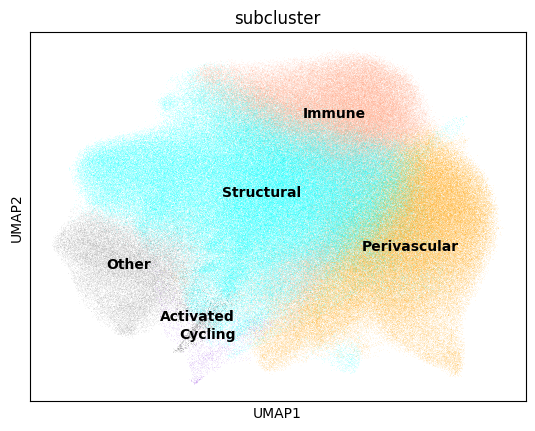

In [23]:
with plt.rc_context(): 
    sc.pl.umap(adata, color = ['subcluster'], legend_loc = "on data", palette=subcluster_colors, show=False)
    plt.savefig("Fib_subclustered.pdf", bbox_inches="tight")

- Cluster 0 are structural fibroblasts - LUM/ECM1/FIBIN
- Cluster 1 are immune-interacting fibroblasts (IL15RA/C1RL/ELANE)
- Cluster 2 are activated fibroblasts (THBS1/FOSL1/PPARD)
- Cluster 3 are perivascular - COL4A5/EPHA3
- Cluster 4 are structural fibroblasts - COL28A1/PXDNL/ROBO1
- Cluster 5 are cycling fibroblasts (CENPI/SKA1/MCM10)
- Cluster 6 is mostly from one study

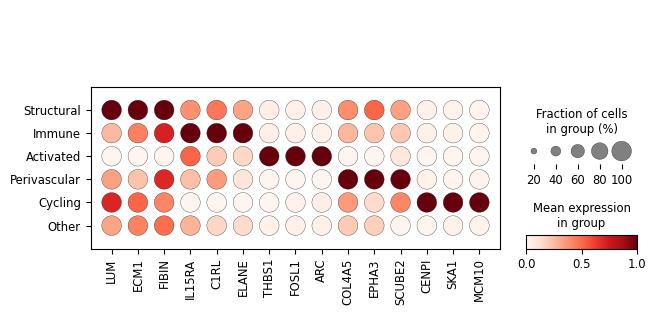

In [24]:
with plt.rc_context(): 
    sc.pl.dotplot(adata, var_names = ["LUM", "ECM1", "FIBIN",
                                  "IL15RA", "C1RL", "ELANE", 
                                  "THBS1", "FOSL1", "ARC", 
                                  "COL4A5", "EPHA3", "SCUBE2",
                                     "CENPI", "SKA1", "MCM10"], groupby = "subcluster", 
                  show=False, standard_scale='var', layer="scvi_normalized")
    plt.savefig("Fib_subclustered_dotplot.pdf", bbox_inches="tight")

In [25]:
subcluster_stats = (
    adata.obs['subcluster']
    .value_counts(normalize=False)
    .rename("count")
    .reset_index()
    .rename(columns={"index": "subcluster"})
)

subcluster_stats["proportion"] = subcluster_stats["count"] / subcluster_stats["count"].sum()

print(subcluster_stats)

     subcluster   count  proportion
0    Structural  270182    0.492482
1  Perivascular  141820    0.258506
2        Immune  104747    0.190931
3         Other   27490    0.050108
4       Cycling    2329    0.004245
5     Activated    2045    0.003728
